# Grafici con python

Esistono diverse liberie per fare grafici con python. La più semplice e più usata è <a href="https://matplotlib.org/">```matplotlib```</a> basata su licenza Open Source.

<img style="width: 400px;" src="img/matplotlib.svg">

Matplotlib produce grafici statici che possono essere scritti su files e usati per pubblicazioni. Esistono possibilità di aggiungere animazioni ed interattività che però non esploreremo a fondo in questo corso.
* <a href="https://youtu.be/DAQNHzOcO5A">tutorial su matplotlib</a>

Anche <a href="https://plotly.com/">```plotly```</a> è usata per fare grafici con capacità interattive, soprattutto per essere esportati per il web.

<img style="width: 400px;" src="img/plotly-logo.png">

Plotly supporta anche R e javascript. Ha codice Open Source. La compamny che sviluppa plotly rilascia anche software a pagamento. I grafici prodotti con plotly sono naturalmente interattivi e adatti per la pubblicazione su siti web.
* <a href="https://plotly.com/python/">Plotly in python</a>

In [2]:
import matplotlib.pyplot as plt
# vedremo meglio dopo le principali funzionalità di numpy
import numpy as np
import math
import time

In [14]:
x = np.linspace(-20, 20, 2001)

In [15]:
x

array([-20.  , -19.98, -19.96, ...,  19.96,  19.98,  20.  ], shape=(2001,))

Di seguito, commentato, il codice che sarebbe più naturale in programmazione procedurale:

In [16]:
# x = []
# for i in range(2001):
#     x.append(-20 + i*0.02)

In [17]:
# x = [-20 + i*0.02 for i in range(2001)]

In python il modo più efficiente di programmare è tentare di sintetizzare il flusso del codice utilizzando i costrutti del linguaggio o delle librerie disponibili.

Quello che segue è un esempio di codice che **non** è implementato in modo efficiente in python:

In [18]:
def my_fun(x):
    if x == 0: return 1.0
    else: return math.sin(x)/x

In [24]:
start_time = time.time()
y = np.empty_like(x)
for i in range(len(x)):
    y[i] = my_fun(x[i])
print("time:", "{:.5f}s".format(time.time() - start_time))

time: 0.00185s


In [22]:
np.sin(x)

array([-0.91294525, -0.90460157, -0.89589606, ...,  0.89589606,
        0.90460157,  0.91294525], shape=(2001,))

Lo stesso codice può essere espresso in modo molto più conciso, ed in genere è anche più veloce:

In [23]:
#f = lambda x : 1.0 if x==0 else math.sin(x)/x
#vf = np.vectorize(f)
vf = np.vectorize(my_fun)
start_time = time.time()
y = vf(x)
print("time:", "{:.5f}s".format(time.time()-start_time))

time: 0.00104s


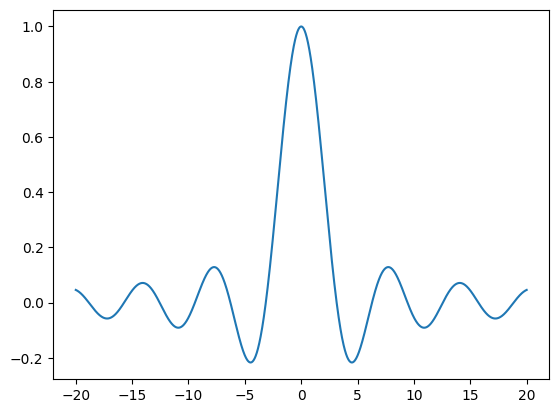

In [25]:
plt.plot(x, y)
plt.show()

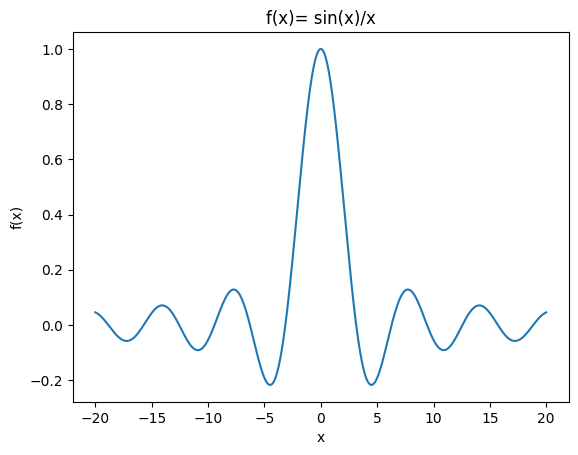

In [31]:
plt.plot(x,y)
plt.title("f(x)= sin(x)/x")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

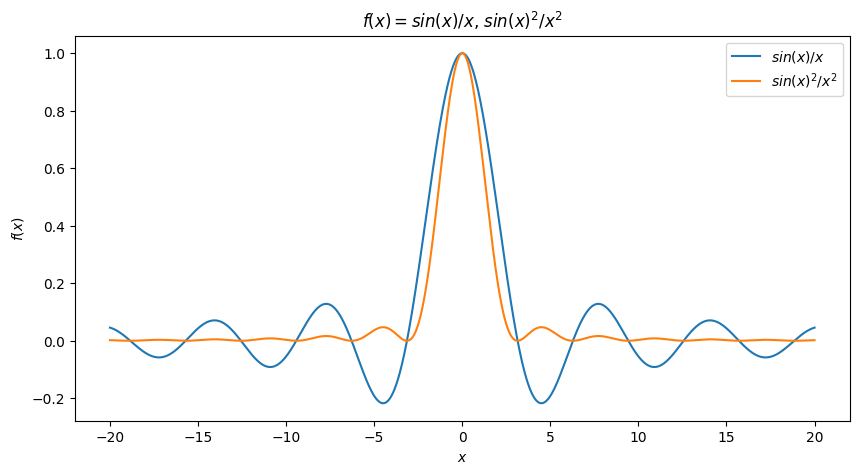

In [37]:
y2 = y**2
# width, height in inches; resolution in dpi
plt.figure(figsize=(10,5))
plt.plot(x, y, label = "$sin(x)/x$")
plt.plot(x, y2, label = "$sin(x)^2/x^2$")
plt.title("$f(x)= sin(x)/x$, $sin(x)^2/x^2$")
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
import os
if not os.path.exists('output'):
    os.makedirs('output')
plt.savefig('output/sinx_x.png', dpi=120)
plt.show()

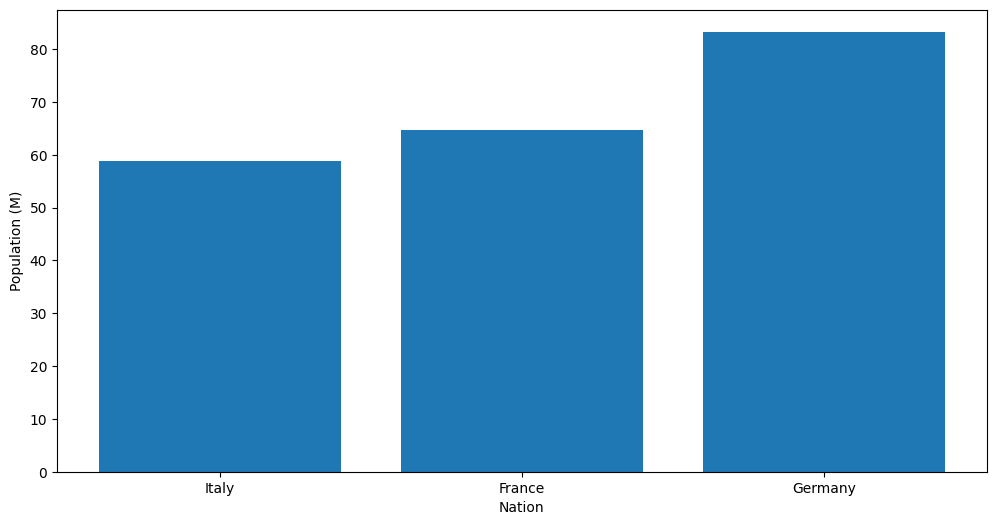

In [38]:
nation = ["Italy", "France", "Germany"]
population = [58.871, 64.757, 83.295]
plt.figure(figsize=(12,6))
plt.xlabel('Nation')
plt.ylabel('Population (M)')
plt.bar(nation, population)
plt.show()

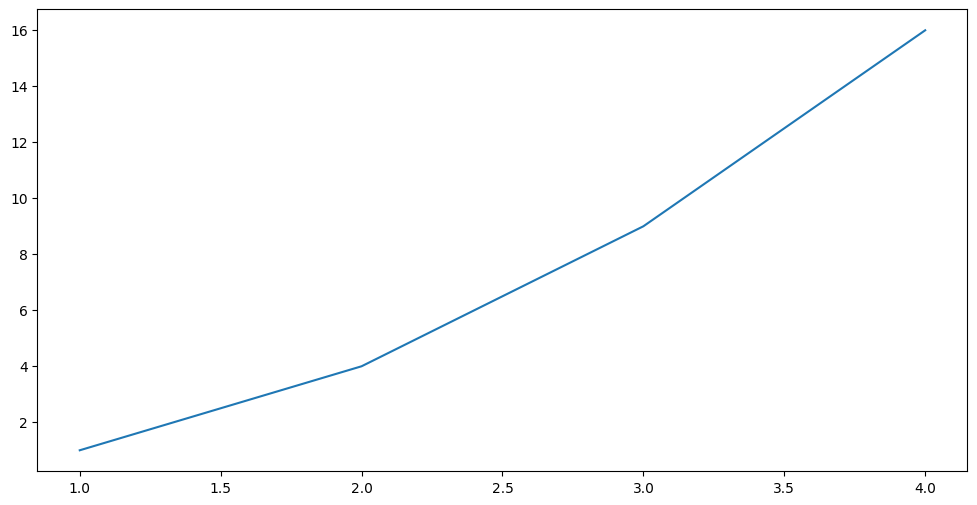

In [39]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot([1,2,3,4],[1,4,9,16])

Text(0.5, 0.98, 'Subplots')

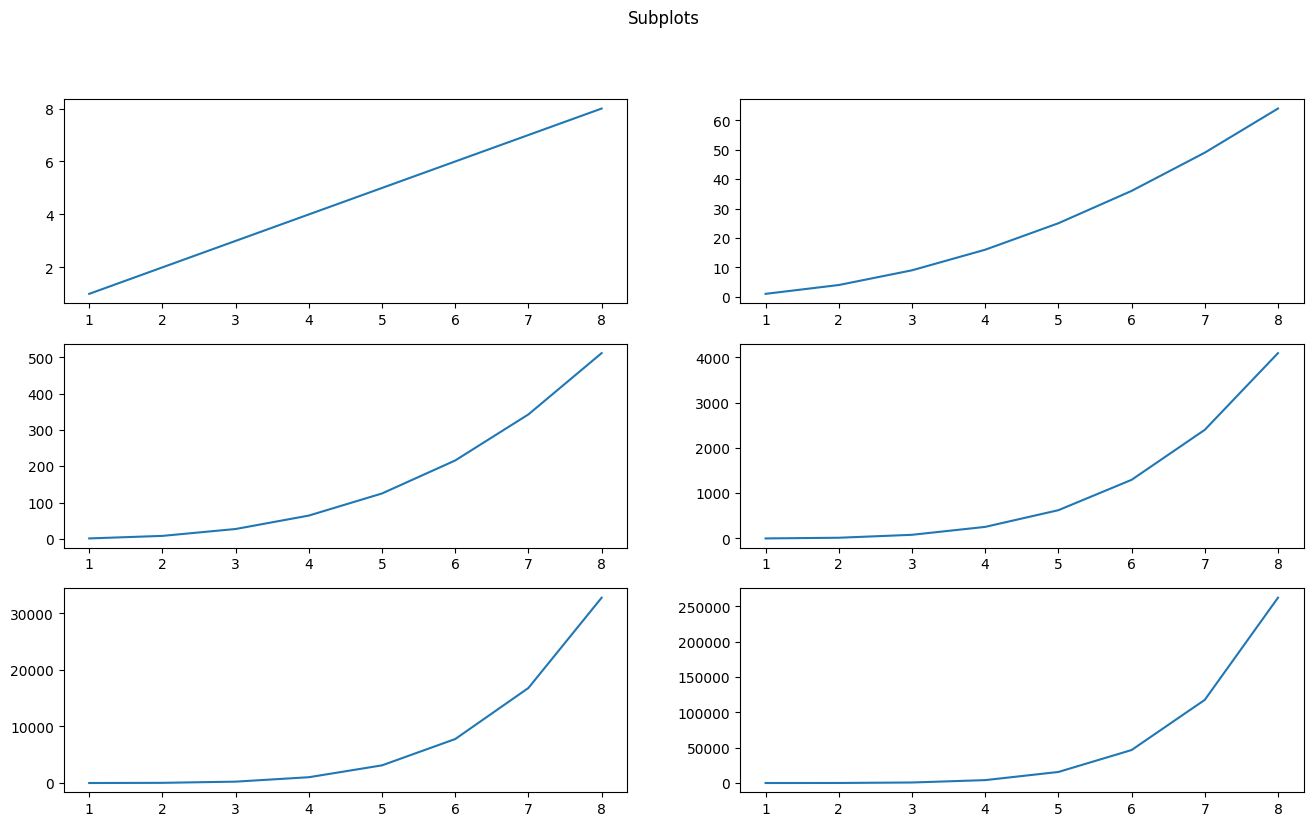

In [14]:
fig, ax = plt.subplots(3, 2, figsize=(16,9))
x = np.array([1,2,3,4,5,6,7,8])
ax[0,0].plot(x,x)
ax[0,1].plot(x,x**2)
ax[1,0].plot(x,x**3)
ax[1,1].plot(x,x**4)
ax[2,0].plot(x,x**5)
ax[2,1].plot(x,x**6)
fig.suptitle('Subplots')

# Esempio di grafici con Plotly

Si tratta di grafici che hanno funzioni interattive e possono essere esportati per il web.

In [40]:
import plotly.graph_objects as go

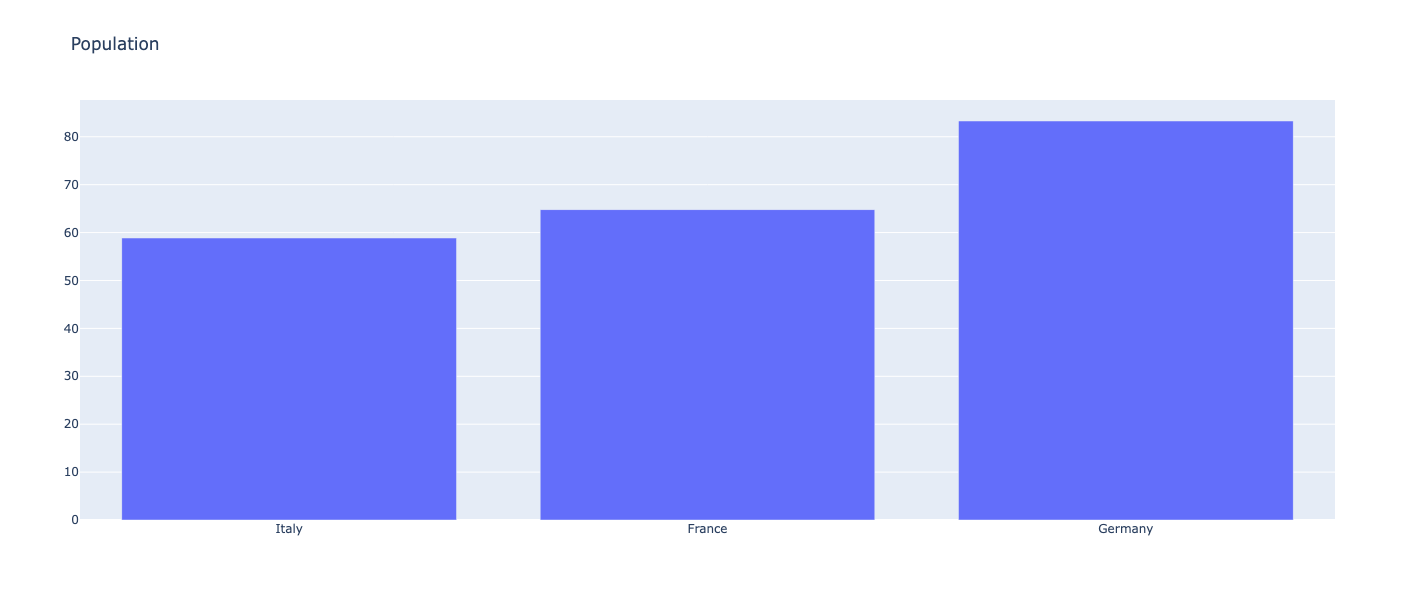

In [41]:
fig = go.Figure(
    data=[go.Bar(x=nation, y=population)],
    layout = go.Layout(width=1000, height=600, title="Population")
)
fig.show()

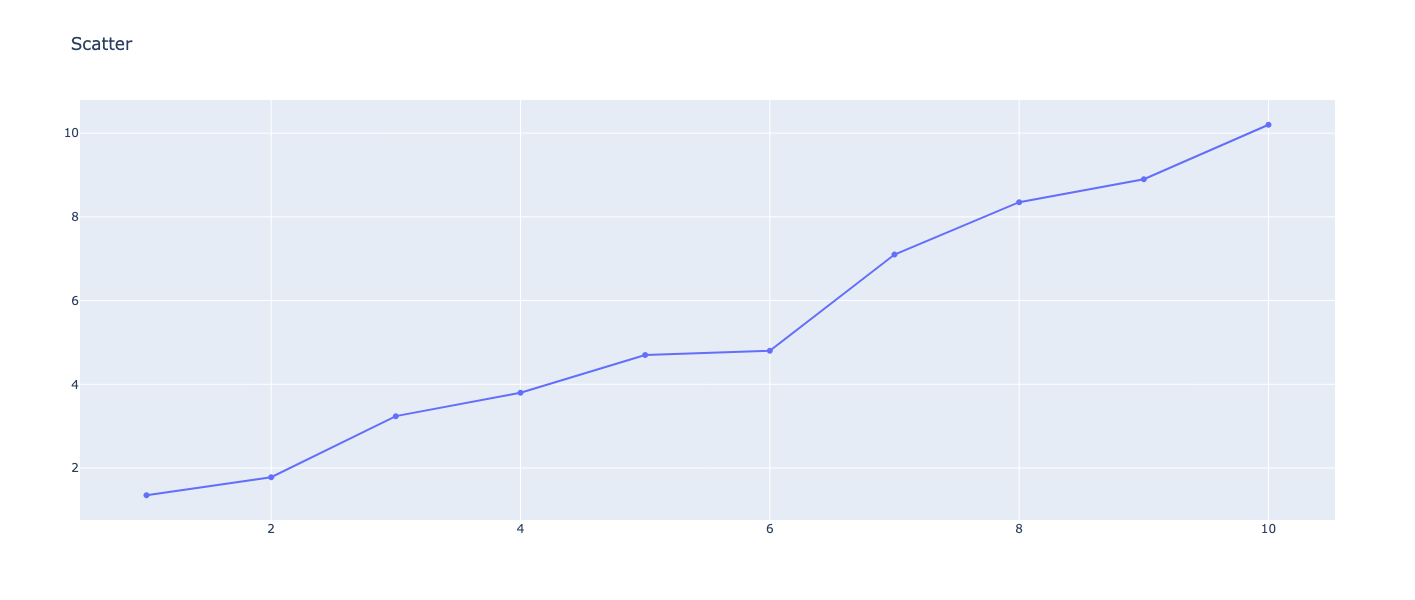

In [42]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [1.35, 1.78, 3.24, 3.8, 4.7, 4.8, 7.1, 8.35, 8.9, 10.2]
fig = go.Figure(
    data=[go.Scatter(x=x, y=y)],
    layout = go.Layout(width=1000, height=600, title="Scatter")
)
fig.show()

Esempio di sito web realizzato con plotly:
    
<a href="https://covid19.infn.it/">https://covid19.infn.it/</a>

# Spunti per esercizi

* Provare a graficare diverse funzioni esponenziali decrescenti $e^{-\lambda x}$ sovrapposte con diversi valori del parametro $\lambda$
* Trovare in rete come si può colorare l'area sotto la curva di una funzione prescelta